SELECTION METHODE : ROULETTE
CROSSOVER METHODE : UNIFORM
MUTATION METHODE : BITFLIP
Baseline Accuracy: 0.7447916666666666

Starting Genetic Algorithm Evolution...
Gen 5/30 | Best: 0.7927 | Size: 5
Gen 10/30 | Best: 0.7927 | Size: 5
Gen 15/30 | Best: 0.7927 | Size: 5
Gen 20/30 | Best: 0.7927 | Size: 5
Gen 25/30 | Best: 0.7927 | Size: 5
Gen 30/30 | Best: 0.7927 | Size: 5

GA RESULTS
Best Validation Fitness: 0.7927
Final Test Accuracy:     0.7403
Selected Features (5): ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigree']

Running Feature Frequency Analysis (20 runs)...
Completed 5/20 runs...
Completed 10/20 runs...
Completed 15/20 runs...
Completed 20/20 runs...


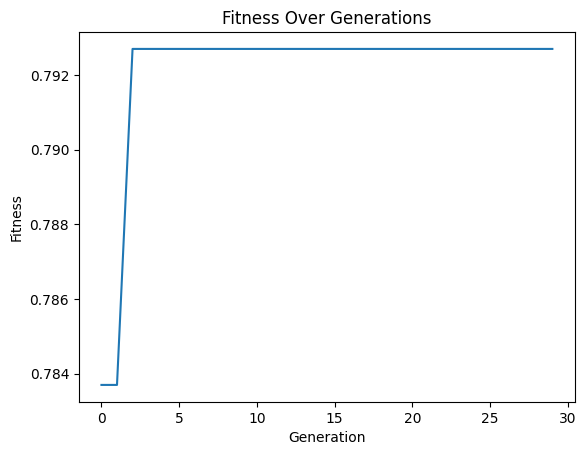

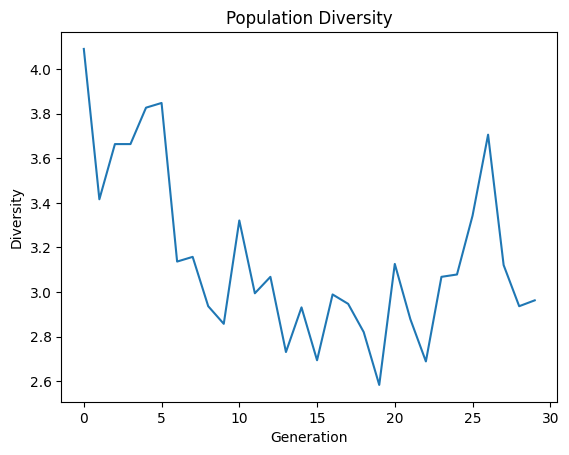

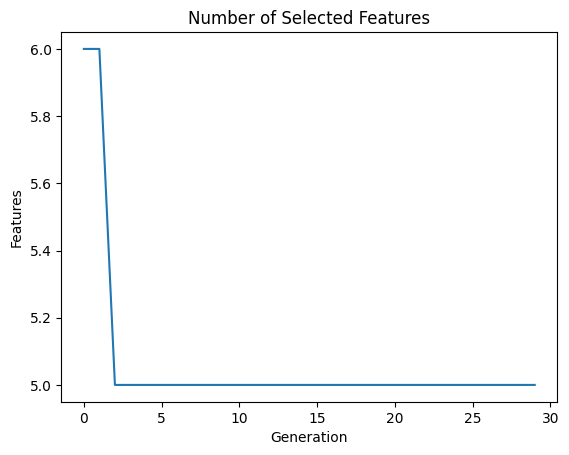

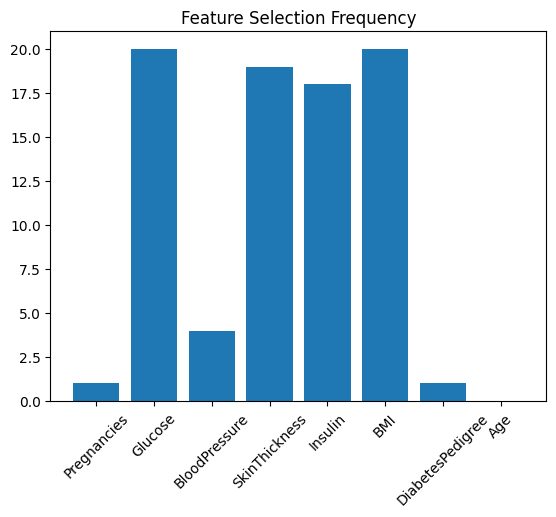

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')


# ===============================
# Genetic Algorithm Class
# ===============================
class GeneticAlgorithmFeatureSelection:

    def __init__(self, X, y, pop_size=30, generations=50,
                 mutation_rate=0.05, crossover_rate=0.8,
                 selection_method="tournament",
                 crossover_method="single",
                 mutation_method="bitflip",
                 random_state=42):

        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.selection_method = selection_method
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.n_features = X.shape[1]
        self.random_state = random_state

        # Memoization cache
        self.fitness_cache = {}

        # Train / Validation / Test split (60 / 20 / 20)
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=0.20, random_state=self.random_state)
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=self.random_state) # 0.25 * 0.8 = 0.2

        # Scaling
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_val = scaler.transform(self.X_val)
        self.X_test = scaler.transform(self.X_test)

    # ===============================
    # Chromosome
    # ===============================
    def create_chromosome(self):
        chromosome = np.random.randint(0, 2, self.n_features)
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1
        return chromosome

    # ===============================
    # Fitness Function
    # ===============================
    def fitness_accuracy(self, chromosome):
        # Memoization check
        chrom_tuple = tuple(chromosome)
        if chrom_tuple in self.fitness_cache:
            return self.fitness_cache[chrom_tuple]

        features = np.where(chromosome == 1)[0]

        if len(features) == 0:
            return 0

        model = RandomForestClassifier(n_estimators=50, random_state=self.random_state)
        model.fit(self.X_train[:, features], self.y_train)
        
        # USE VALIDATION SET FOR FITNESS
        preds = model.predict(self.X_val[:, features])
        acc = accuracy_score(self.y_val, preds)

        # penalty for many features (penalize if more than 50% are used)
        penalty = 0.02 * (len(features) / self.n_features)
        score = acc - penalty
        
        # Save to cache
        self.fitness_cache[chrom_tuple] = score
        return score

    # ===============================
    # Selection Methods
    # ===============================
    def selection(self, population, fitness_scores):

        if self.selection_method == "tournament":
            i, j = random.sample(range(len(population)), 2)
            return population[i] if fitness_scores[i] > fitness_scores[j] else population[j]

        elif self.selection_method == "roulette":
            fitness_array = np.array(fitness_scores)
            total = fitness_array.sum()
            if total == 0:
                return population[np.random.randint(len(population))]
            probs = fitness_array / total
            idx = np.random.choice(len(population), p=probs)
            return population[idx]

        elif self.selection_method == "random":
            return population[np.random.randint(len(population))]

        elif self.selection_method == "rank":
            ranked = np.argsort(fitness_scores)
            probs = np.linspace(1, 2, len(population))
            probs = probs / probs.sum()
            idx = np.random.choice(ranked, p=probs)
            return population[idx]

    # ===============================
    # Crossover Methods
    # ===============================
    def crossover(self, p1, p2):

        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()

        if self.crossover_method == "single":
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])

        elif self.crossover_method == "two":
            pt1 = random.randint(1, self.n_features - 2)
            pt2 = random.randint(pt1, self.n_features - 1)
            c1 = p1.copy()
            c2 = p2.copy()
            c1[pt1:pt2] = p2[pt1:pt2]
            c2[pt1:pt2] = p1[pt1:pt2]

        elif self.crossover_method == "uniform":
            c1 = p1.copy()
            c2 = p2.copy()
            for i in range(self.n_features):
                if random.random() < 0.5:
                    c1[i] = p2[i]
                    c2[i] = p1[i]

        return c1, c2

    # ===============================
    # Mutation Methods
    # ===============================
    def mutation(self, chromosome):

        if self.mutation_method == "bitflip":
            for i in range(self.n_features):
                if random.random() < self.mutation_rate:
                    chromosome[i] = 1 - chromosome[i]

        elif self.mutation_method == "swap":
            i, j = np.random.randint(0, self.n_features, 2)
            chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

        elif self.mutation_method == "inversion":
            i, j = sorted(np.random.randint(0, self.n_features, 2))
            chromosome[i:j] = chromosome[i:j][::-1]

        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1

        return chromosome

    # ===============================
    # Run Genetic Algorithm
    # ===============================
    def run_1(self, verbose=True):

        population = [self.create_chromosome() for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        fitness_history = []
        diversity_history = []
        feature_count_history = []

        for gen in range(self.generations):

            fitness_scores = [self.fitness_accuracy(c) for c in population]

            # Best individual
            idx = np.argmax(fitness_scores)
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_chromosome = population[idx].copy()

            fitness_history.append(best_fitness)
            feature_count_history.append(np.sum(best_chromosome))

            # Diversity (Vectorized Hamming Distance calculation)
            pop_array = np.array(population)
            # Efficiently compute average distance between all pairs
            # Matrix: (pop_size, pop_size)
            diff = (pop_array[:, None, :] != pop_array[None, :, :]).sum(axis=2)
            diversity = np.mean(diff[np.triu_indices(self.pop_size, k=1)])
            diversity_history.append(diversity)

            if verbose and (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}/{self.generations} | Best: {best_fitness:.4f} | Size: {np.sum(best_chromosome)}")

            # New population
            new_population = [best_chromosome]

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitness_scores)
                p2 = self.selection(population, fitness_scores)

                c1, c2 = self.crossover(p1, p2)

                new_population.append(self.mutation(c1))
                if len(new_population) < self.pop_size:
                    new_population.append(self.mutation(c2))

            population = new_population

        return best_chromosome, best_fitness, fitness_history, diversity_history, feature_count_history


# ===============================
# Load Pima Dataset
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
    df = pd.read_csv(url, names=names)
    return df


# ===============================
# MAIN
# ===============================
def main():


    print("SELECTION METHODE : ROULETTE")
    print("CROSSOVER METHODE : UNIFORM")
    print("MUTATION METHODE : BITFLIP")

    df = load_data()
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    feature_names = X.columns

    # Baseline
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    baseline = accuracy_score(y_test, model.predict(X_test))
    print("Baseline Accuracy:", baseline)

    # Run GA
    ga = GeneticAlgorithmFeatureSelection(
        X.values, y.values,
        selection_method="roulette",
        crossover_method="single",
        mutation_method="bitflip",
        generations=30, # Reduced for faster demo
        pop_size=20
    )

    print("\nStarting Genetic Algorithm Evolution...")
    best_mask, best_fitness, fitness_hist, diversity_hist, feat_hist = ga.run_1()

    selected_features = [feature_names[i] for i in range(len(best_mask)) if best_mask[i]]

    # FINAL EVALUATION ON HELD-OUT TEST SET (Unseen by GA)
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(ga.X_train[:, best_mask == 1], ga.y_train)
    test_preds = final_model.predict(ga.X_test[:, best_mask == 1])
    final_test_acc = accuracy_score(ga.y_test, test_preds)

    print("\n" + "="*30)
    print("GA RESULTS")
    print("="*30)
    print(f"Best Validation Fitness: {best_fitness:.4f}")
    print(f"Final Test Accuracy:     {final_test_acc:.4f}")
    print(f"Selected Features ({len(selected_features)}): {selected_features}")
    print("="*30)

    # ===============================
    # Visualizations
    # ===============================
    plt.figure()
    plt.plot(fitness_hist)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.savefig("fitness.png")

    plt.figure()
    plt.plot(diversity_hist)
    plt.title("Population Diversity")
    plt.xlabel("Generation")
    plt.ylabel("Diversity")
    plt.savefig("diversity.png")

    plt.figure()
    plt.plot(feat_hist)
    plt.title("Number of Selected Features")
    plt.xlabel("Generation")
    plt.ylabel("Features")
    plt.savefig("features.png")

    # Feature frequency (Optimized with memoization)
    print("\nRunning Feature Frequency Analysis (20 runs)...")
    freq = np.zeros(len(feature_names))
    for i in range(20):
        # We reuse the same 'ga' object to benefit from the growing self.fitness_cache
        mask, _, _, _, _ = ga.run_1(verbose=False)
        freq += mask
        if (i+1) % 5 == 0:
            print(f"Completed {i+1}/20 runs...")

    plt.figure()
    plt.bar(feature_names, freq)
    plt.xticks(rotation=45)
    plt.title("Feature Selection Frequency")
    plt.savefig("feature_frequency.png")


if __name__ == "__main__":
    main()

SELECTION METHODE : ROULETTE
CROSSOVER METHODE : UNIFORM
MUTATION METHODE : BITFLIP
Baseline Accuracy: 0.71875

Starting Genetic Algorithm Evolution...
Gen 5/30 | Best: 0.6709 | Size: 4
Gen 10/30 | Best: 0.6713 | Size: 4
Gen 15/30 | Best: 0.6713 | Size: 4
Gen 20/30 | Best: 0.6713 | Size: 4
Gen 25/30 | Best: 0.6713 | Size: 4
Gen 30/30 | Best: 0.6713 | Size: 4

GA RESULTS
Best Validation Fitness: 0.6713
Final Test Accuracy:     0.7013
Selected Features (4): ['Glucose', 'SkinThickness', 'Insulin', 'BMI']

Running Feature Frequency Analysis (20 runs)...


KeyboardInterrupt: 

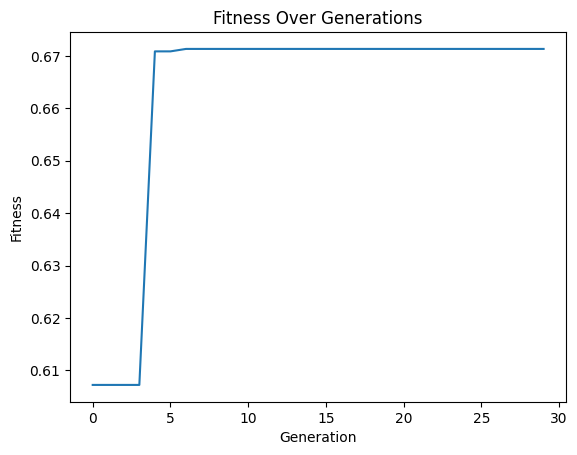

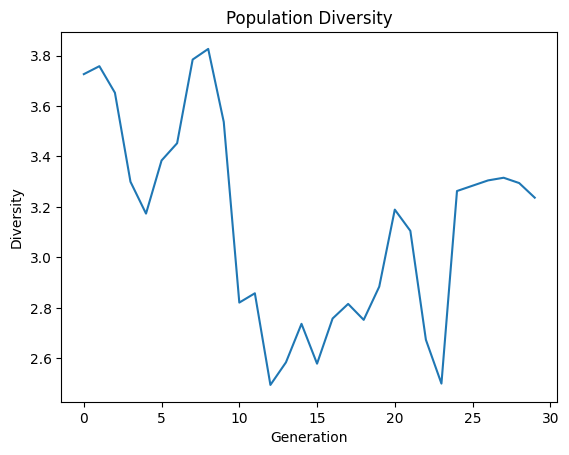

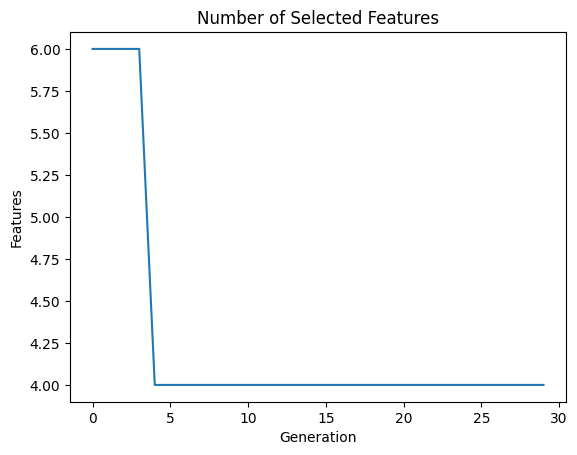

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')


# ===============================
# Genetic Algorithm Class
# ===============================
class GeneticAlgorithmFeatureSelection:

    def __init__(self, X, y, pop_size=30, generations=50,
                 mutation_rate=0.05, crossover_rate=0.8,
                 selection_method="tournament",
                 crossover_method="single",
                 mutation_method="bitflip",
                 random_state=42):

        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.selection_method = selection_method
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.n_features = X.shape[1]
        self.random_state = random_state

        # Memoization cache
        self.fitness_cache = {}

        # Train / Validation / Test split (60 / 20 / 20)
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=0.20, random_state=self.random_state)
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=self.random_state) # 0.25 * 0.8 = 0.2

        # Scaling
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_val = scaler.transform(self.X_val)
        self.X_test = scaler.transform(self.X_test)

    # ===============================
    # Chromosome
    # ===============================
    def create_chromosome(self):
        chromosome = np.random.randint(0, 2, self.n_features)
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1
        return chromosome

    # ===============================
    # Fitness Function
    # ===============================
    def fitness_f1(self, chromosome):

        features = np.where(chromosome == 1)[0]
        if len(features) == 0:
            return 0

        model = RandomForestClassifier(n_estimators=50, random_state=self.random_state)
        model.fit(self.X_train[:, features], self.y_train)

        preds = model.predict(self.X_val[:, features])

        f1 = f1_score(self.y_val, preds)

        penalty = 0.02 * (len(features) / self.n_features)

        return f1 - penalty

    # ===============================
    # Selection Methods
    # ===============================
    def selection(self, population, fitness_scores):

        if self.selection_method == "tournament":
            i, j = random.sample(range(len(population)), 2)
            return population[i] if fitness_scores[i] > fitness_scores[j] else population[j]

        elif self.selection_method == "roulette":
            fitness_array = np.array(fitness_scores)
            total = fitness_array.sum()
            if total == 0:
                return population[np.random.randint(len(population))]
            probs = fitness_array / total
            idx = np.random.choice(len(population), p=probs)
            return population[idx]

        elif self.selection_method == "random":
            return population[np.random.randint(len(population))]

        elif self.selection_method == "rank":
            ranked = np.argsort(fitness_scores)
            probs = np.linspace(1, 2, len(population))
            probs = probs / probs.sum()
            idx = np.random.choice(ranked, p=probs)
            return population[idx]

    # ===============================
    # Crossover Methods
    # ===============================
    def crossover(self, p1, p2):

        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()

        if self.crossover_method == "single":
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])

        elif self.crossover_method == "two":
            pt1 = random.randint(1, self.n_features - 2)
            pt2 = random.randint(pt1, self.n_features - 1)
            c1 = p1.copy()
            c2 = p2.copy()
            c1[pt1:pt2] = p2[pt1:pt2]
            c2[pt1:pt2] = p1[pt1:pt2]

        elif self.crossover_method == "uniform":
            c1 = p1.copy()
            c2 = p2.copy()
            for i in range(self.n_features):
                if random.random() < 0.5:
                    c1[i] = p2[i]
                    c2[i] = p1[i]

        return c1, c2

    # ===============================
    # Mutation Methods
    # ===============================
    def mutation(self, chromosome):

        if self.mutation_method == "bitflip":
            for i in range(self.n_features):
                if random.random() < self.mutation_rate:
                    chromosome[i] = 1 - chromosome[i]

        elif self.mutation_method == "swap":
            i, j = np.random.randint(0, self.n_features, 2)
            chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

        elif self.mutation_method == "inversion":
            i, j = sorted(np.random.randint(0, self.n_features, 2))
            chromosome[i:j] = chromosome[i:j][::-1]

        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1

        return chromosome

    # ===============================
    # Run Genetic Algorithm
    # ===============================
    def run_2(self, verbose=True):

        population = [self.create_chromosome() for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        fitness_history = []
        diversity_history = []
        feature_count_history = []

        for gen in range(self.generations):

            fitness_scores = [self.fitness_f1(c) for c in population]

            # Best individual
            idx = np.argmax(fitness_scores)
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_chromosome = population[idx].copy()

            fitness_history.append(best_fitness)
            feature_count_history.append(np.sum(best_chromosome))

            # Diversity (Vectorized Hamming Distance calculation)
            pop_array = np.array(population)
            # Efficiently compute average distance between all pairs
            # Matrix: (pop_size, pop_size)
            diff = (pop_array[:, None, :] != pop_array[None, :, :]).sum(axis=2)
            diversity = np.mean(diff[np.triu_indices(self.pop_size, k=1)])
            diversity_history.append(diversity)

            if verbose and (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}/{self.generations} | Best: {best_fitness:.4f} | Size: {np.sum(best_chromosome)}")

            # New population
            new_population = [best_chromosome]

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitness_scores)
                p2 = self.selection(population, fitness_scores)

                c1, c2 = self.crossover(p1, p2)

                new_population.append(self.mutation(c1))
                if len(new_population) < self.pop_size:
                    new_population.append(self.mutation(c2))

            population = new_population

        return best_chromosome, best_fitness, fitness_history, diversity_history, feature_count_history


# ===============================
# Load Pima Dataset
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
    df = pd.read_csv(url, names=names)
    return df


# ===============================
# MAIN
# ===============================
def main():


    print("SELECTION METHODE : ROULETTE")
    print("CROSSOVER METHODE : UNIFORM")
    print("MUTATION METHODE : BITFLIP")

    df = load_data()
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    feature_names = X.columns

    # Baseline
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    baseline = accuracy_score(y_test, model.predict(X_test))
    print("Baseline Accuracy:", baseline)

    # Run GA
    ga = GeneticAlgorithmFeatureSelection(
        X.values, y.values,
        selection_method="roulette",
        crossover_method="single",
        mutation_method="bitflip",
        generations=30, # Reduced for faster demo
        pop_size=20
    )

    print("\nStarting Genetic Algorithm Evolution...")
    best_mask, best_fitness, fitness_hist, diversity_hist, feat_hist = ga.run_2()
    selected_features = [feature_names[i] for i in range(len(best_mask)) if best_mask[i]]

    # FINAL EVALUATION ON HELD-OUT TEST SET (Unseen by GA)
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(ga.X_train[:, best_mask == 1], ga.y_train)
    test_preds = final_model.predict(ga.X_test[:, best_mask == 1])
    final_test_acc = accuracy_score(ga.y_test, test_preds)

    print("\n" + "="*30)
    print("GA RESULTS")
    print("="*30)
    print(f"Best Validation Fitness: {best_fitness:.4f}")
    print(f"Final Test Accuracy:     {final_test_acc:.4f}")
    print(f"Selected Features ({len(selected_features)}): {selected_features}")
    print("="*30)

    # ===============================
    # Visualizations
    # ===============================
    plt.figure()
    plt.plot(fitness_hist)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.savefig("fitness.png")

    plt.figure()
    plt.plot(diversity_hist)
    plt.title("Population Diversity")
    plt.xlabel("Generation")
    plt.ylabel("Diversity")
    plt.savefig("diversity.png")

    plt.figure()
    plt.plot(feat_hist)
    plt.title("Number of Selected Features")
    plt.xlabel("Generation")
    plt.ylabel("Features")
    plt.savefig("features.png")

    # Feature frequency (Optimized with memoization)
    print("\nRunning Feature Frequency Analysis (20 runs)...")
    freq = np.zeros(len(feature_names))
    for i in range(20):
        # We reuse the same 'ga' object to benefit from the growing self.fitness_cache
        mask, _, _, _, _ = ga.run_2(verbose=False)
        freq += mask
        if (i+1) % 5 == 0:
            print(f"Completed {i+1}/20 runs...")

    plt.figure()
    plt.bar(feature_names, freq)
    plt.xticks(rotation=45)
    plt.title("Feature Selection Frequency")
    plt.savefig("feature_frequency.png")


if __name__ == "__main__":
    main()

SELECTION METHODE : ROULETTE
CROSSOVER METHODE : UNIFORM
MUTATION METHODE : BITFLIP
Baseline Accuracy: 0.7395833333333334

Starting Genetic Algorithm Evolution...
Gen 5/30 | Best: 0.7108 | Size: 3
Gen 10/30 | Best: 0.7298 | Size: 4
Gen 15/30 | Best: 0.7298 | Size: 4
Gen 20/30 | Best: 0.7311 | Size: 4
Gen 25/30 | Best: 0.7311 | Size: 4
Gen 30/30 | Best: 0.7311 | Size: 4

GA RESULTS
Best Validation Fitness: 0.7311
Final Test Accuracy:     0.7078
Selected Features (4): ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']

Running Feature Frequency Analysis (20 runs)...


KeyboardInterrupt: 

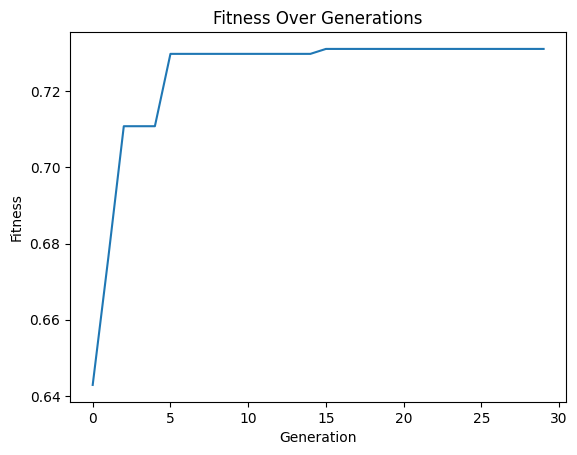

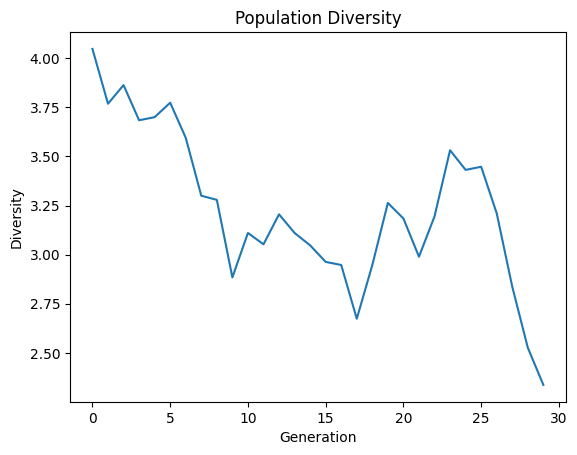

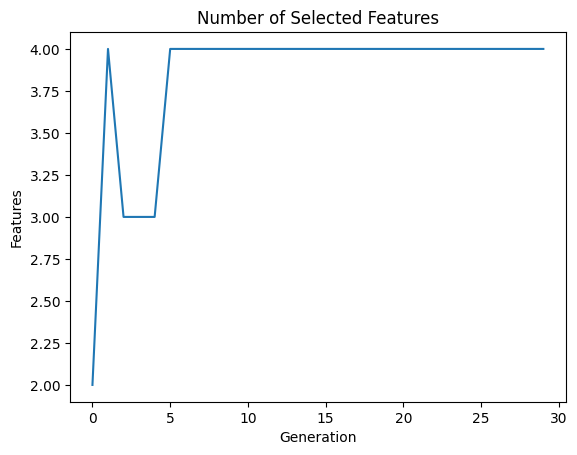

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , roc_auc_score
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')


# ===============================
# Genetic Algorithm Class
# ===============================
class GeneticAlgorithmFeatureSelection:

    def __init__(self, X, y, pop_size=30, generations=50,
                 mutation_rate=0.05, crossover_rate=0.8,
                 selection_method="tournament",
                 crossover_method="single",
                 mutation_method="bitflip",
                 random_state=42):

        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.selection_method = selection_method
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.n_features = X.shape[1]
        self.random_state = random_state

        # Memoization cache
        self.fitness_cache = {}

        # Train / Validation / Test split (60 / 20 / 20)
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=0.20, random_state=self.random_state)
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=self.random_state) # 0.25 * 0.8 = 0.2

        # Scaling
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_val = scaler.transform(self.X_val)
        self.X_test = scaler.transform(self.X_test)

    # ===============================
    # Chromosome
    # ===============================
    def create_chromosome(self):
        chromosome = np.random.randint(0, 2, self.n_features)
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1
        return chromosome

    # ===============================
    # Fitness Function
    # ===============================
    def fitness_combined(self, chromosome):

        features = np.where(chromosome == 1)[0]
        if len(features) == 0:
            return 0

        model = RandomForestClassifier(n_estimators=50, random_state=self.random_state)
        model.fit(self.X_train[:, features], self.y_train)

        preds = model.predict(self.X_val[:, features])
        proba = model.predict_proba(self.X_val[:, features])[:,1]

        f1 = f1_score(self.y_val, preds)
        roc = roc_auc_score(self.y_val, proba)

        penalty = 0.02 * (len(features) / self.n_features)

        return 0.7 * f1 + 0.3 * roc - penalty

    # ===============================
    # Selection Methods
    # ===============================
    def selection(self, population, fitness_scores):

        if self.selection_method == "tournament":
            i, j = random.sample(range(len(population)), 2)
            return population[i] if fitness_scores[i] > fitness_scores[j] else population[j]

        elif self.selection_method == "roulette":
            fitness_array = np.array(fitness_scores)
            total = fitness_array.sum()
            if total == 0:
                return population[np.random.randint(len(population))]
            probs = fitness_array / total
            idx = np.random.choice(len(population), p=probs)
            return population[idx]

        elif self.selection_method == "random":
            return population[np.random.randint(len(population))]

        elif self.selection_method == "rank":
            ranked = np.argsort(fitness_scores)
            probs = np.linspace(1, 2, len(population))
            probs = probs / probs.sum()
            idx = np.random.choice(ranked, p=probs)
            return population[idx]

    # ===============================
    # Crossover Methods
    # ===============================
    def crossover(self, p1, p2):

        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()

        if self.crossover_method == "single":
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])

        elif self.crossover_method == "two":
            pt1 = random.randint(1, self.n_features - 2)
            pt2 = random.randint(pt1, self.n_features - 1)
            c1 = p1.copy()
            c2 = p2.copy()
            c1[pt1:pt2] = p2[pt1:pt2]
            c2[pt1:pt2] = p1[pt1:pt2]

        elif self.crossover_method == "uniform":
            c1 = p1.copy()
            c2 = p2.copy()
            for i in range(self.n_features):
                if random.random() < 0.5:
                    c1[i] = p2[i]
                    c2[i] = p1[i]

        return c1, c2

    # ===============================
    # Mutation Methods
    # ===============================
    def mutation(self, chromosome):

        if self.mutation_method == "bitflip":
            for i in range(self.n_features):
                if random.random() < self.mutation_rate:
                    chromosome[i] = 1 - chromosome[i]

        elif self.mutation_method == "swap":
            i, j = np.random.randint(0, self.n_features, 2)
            chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

        elif self.mutation_method == "inversion":
            i, j = sorted(np.random.randint(0, self.n_features, 2))
            chromosome[i:j] = chromosome[i:j][::-1]

        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1

        return chromosome

    # ===============================
    # Run Genetic Algorithm
    # ===============================
    def run_3(self, verbose=True):

        population = [self.create_chromosome() for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        fitness_history = []
        diversity_history = []
        feature_count_history = []

        for gen in range(self.generations):

            fitness_scores = [self.fitness_combined(c) for c in population]

            # Best individual
            idx = np.argmax(fitness_scores)
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_chromosome = population[idx].copy()

            fitness_history.append(best_fitness)
            feature_count_history.append(np.sum(best_chromosome))

            # Diversity (Vectorized Hamming Distance calculation)
            pop_array = np.array(population)
            # Efficiently compute average distance between all pairs
            # Matrix: (pop_size, pop_size)
            diff = (pop_array[:, None, :] != pop_array[None, :, :]).sum(axis=2)
            diversity = np.mean(diff[np.triu_indices(self.pop_size, k=1)])
            diversity_history.append(diversity)

            if verbose and (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}/{self.generations} | Best: {best_fitness:.4f} | Size: {np.sum(best_chromosome)}")

            # New population
            new_population = [best_chromosome]

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitness_scores)
                p2 = self.selection(population, fitness_scores)

                c1, c2 = self.crossover(p1, p2)

                new_population.append(self.mutation(c1))
                if len(new_population) < self.pop_size:
                    new_population.append(self.mutation(c2))

            population = new_population

        return best_chromosome, best_fitness, fitness_history, diversity_history, feature_count_history


# ===============================
# Load Pima Dataset
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
    df = pd.read_csv(url, names=names)
    return df


# ===============================
# MAIN
# ===============================
def main():


    print("SELECTION METHODE : ROULETTE")
    print("CROSSOVER METHODE : UNIFORM")
    print("MUTATION METHODE : BITFLIP")

    df = load_data()
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    feature_names = X.columns

    # Baseline
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    baseline = accuracy_score(y_test, model.predict(X_test))
    print("Baseline Accuracy:", baseline)

    # Run GA
    ga = GeneticAlgorithmFeatureSelection(
        X.values, y.values,
        selection_method="roulette",
        crossover_method="single",
        mutation_method="bitflip",
        generations=30, # Reduced for faster demo
        pop_size=20
    )

    print("\nStarting Genetic Algorithm Evolution...")
    best_mask, best_fitness, fitness_hist, diversity_hist, feat_hist = ga.run_3()
    selected_features = [feature_names[i] for i in range(len(best_mask)) if best_mask[i]]

    # FINAL EVALUATION ON HELD-OUT TEST SET (Unseen by GA)
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(ga.X_train[:, best_mask == 1], ga.y_train)
    test_preds = final_model.predict(ga.X_test[:, best_mask == 1])
    final_test_acc = accuracy_score(ga.y_test, test_preds)

    print("\n" + "="*30)
    print("GA RESULTS")
    print("="*30)
    print(f"Best Validation Fitness: {best_fitness:.4f}")
    print(f"Final Test Accuracy:     {final_test_acc:.4f}")
    print(f"Selected Features ({len(selected_features)}): {selected_features}")
    print("="*30)

    # ===============================
    # Visualizations
    # ===============================
    plt.figure()
    plt.plot(fitness_hist)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.savefig("fitness.png")

    plt.figure()
    plt.plot(diversity_hist)
    plt.title("Population Diversity")
    plt.xlabel("Generation")
    plt.ylabel("Diversity")
    plt.savefig("diversity.png")

    plt.figure()
    plt.plot(feat_hist)
    plt.title("Number of Selected Features")
    plt.xlabel("Generation")
    plt.ylabel("Features")
    plt.savefig("features.png")

    # Feature frequency (Optimized with memoization)
    print("\nRunning Feature Frequency Analysis (20 runs)...")
    freq = np.zeros(len(feature_names))
    for i in range(20):
        # We reuse the same 'ga' object to benefit from the growing self.fitness_cache
        mask, _, _, _, _ = ga.run_3(verbose=False)
        freq += mask
        if (i+1) % 5 == 0:
            print(f"Completed {i+1}/20 runs...")

    plt.figure()
    plt.bar(feature_names, freq)
    plt.xticks(rotation=45)
    plt.title("Feature Selection Frequency")
    plt.savefig("feature_frequency.png")


if __name__ == "__main__":
    main()

SELECTION METHODE : ROULETTE
CROSSOVER METHODE : UNIFORM
MUTATION METHODE : BITFLIP
Baseline Accuracy: 0.765625

Starting Genetic Algorithm Evolution...
Gen 5/30 | Best: 0.7927 | Size: 5
Gen 10/30 | Best: 0.7927 | Size: 5
Gen 15/30 | Best: 0.7927 | Size: 5
Gen 20/30 | Best: 0.7927 | Size: 5
Gen 25/30 | Best: 0.7927 | Size: 5
Gen 30/30 | Best: 0.7927 | Size: 5

GA RESULTS
Best Validation Fitness: 0.7927
Final Test Accuracy:     0.7143
Selected Features (5): ['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']

Running Feature Frequency Analysis (20 runs)...
Completed 5/20 runs...
Completed 10/20 runs...
Completed 15/20 runs...
Completed 20/20 runs...


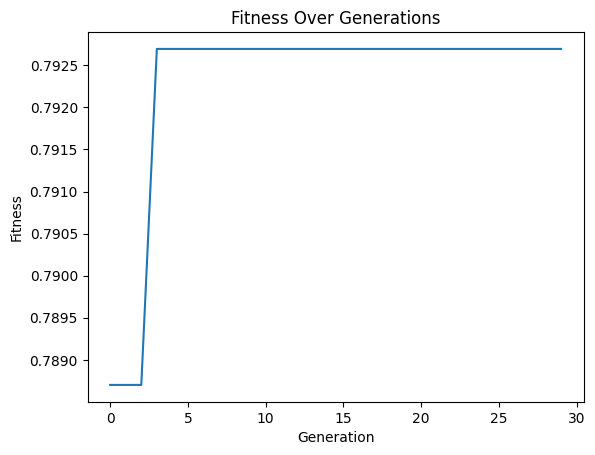

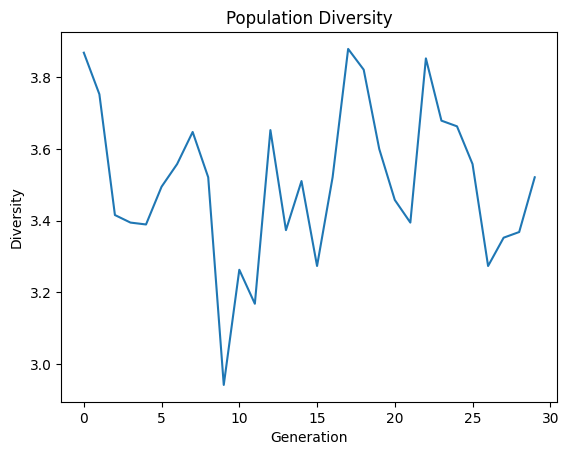

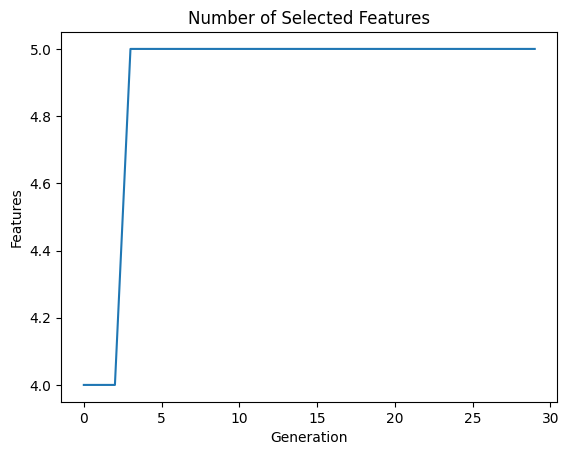

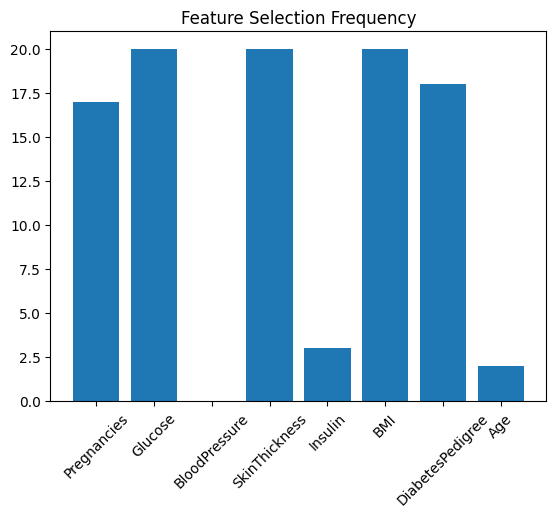

In [8]:
######   logistic regression    #######

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , roc_auc_score
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# ===============================
# Genetic Algorithm Class
# ===============================
class GeneticAlgorithmFeatureSelection:

    def __init__(self, X, y, pop_size=30, generations=50,
                 mutation_rate=0.05, crossover_rate=0.8,
                 selection_method="tournament",
                 crossover_method="single",
                 mutation_method="bitflip",
                 random_state=42):

        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.selection_method = selection_method
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.n_features = X.shape[1]
        self.random_state = random_state

        # Memoization cache
        self.fitness_cache = {}

        # Train / Validation / Test split (60 / 20 / 20)
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=0.20, random_state=self.random_state)
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=self.random_state) # 0.25 * 0.8 = 0.2

        # Scaling
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_val = scaler.transform(self.X_val)
        self.X_test = scaler.transform(self.X_test)

    # ===============================
    # Chromosome
    # ===============================
    def create_chromosome(self):
        chromosome = np.random.randint(0, 2, self.n_features)
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1
        return chromosome

    # ===============================
    # Fitness Function
    # ===============================
    def fitness_logistic(self, chromosome):

        chrom_tuple = tuple(chromosome)
        if chrom_tuple in self.fitness_cache:
            return self.fitness_cache[chrom_tuple]

        features = np.where(chromosome == 1)[0]
        if len(features) == 0:
            return 0

        model = LogisticRegression(max_iter=1000)

        model.fit(self.X_train[:, features], self.y_train)

        preds = model.predict(self.X_val[:, features])

        acc = accuracy_score(self.y_val, preds)

        penalty = 0.02 * (len(features) / self.n_features)

        score = acc - penalty

        # ✅ IMPORTANT
        self.fitness_cache[chrom_tuple] = score
        return score

    # ===============================
    # Selection Methods
    # ===============================
    def selection(self, population, fitness_scores):

        if self.selection_method == "tournament":
            i, j = random.sample(range(len(population)), 2)
            return population[i] if fitness_scores[i] > fitness_scores[j] else population[j]

        elif self.selection_method == "roulette":
            fitness_array = np.array(fitness_scores)
            total = fitness_array.sum()
            if total == 0:
                return population[np.random.randint(len(population))]
            probs = fitness_array / total
            idx = np.random.choice(len(population), p=probs)
            return population[idx]

        elif self.selection_method == "random":
            return population[np.random.randint(len(population))]

        elif self.selection_method == "rank":
            ranked = np.argsort(fitness_scores)
            probs = np.linspace(1, 2, len(population))
            probs = probs / probs.sum()
            idx = np.random.choice(ranked, p=probs)
            return population[idx]

    # ===============================
    # Crossover Methods
    # ===============================
    def crossover(self, p1, p2):

        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()

        if self.crossover_method == "single":
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])

        elif self.crossover_method == "two":
            pt1 = random.randint(1, self.n_features - 2)
            pt2 = random.randint(pt1, self.n_features - 1)
            c1 = p1.copy()
            c2 = p2.copy()
            c1[pt1:pt2] = p2[pt1:pt2]
            c2[pt1:pt2] = p1[pt1:pt2]

        elif self.crossover_method == "uniform":
            c1 = p1.copy()
            c2 = p2.copy()
            for i in range(self.n_features):
                if random.random() < 0.5:
                    c1[i] = p2[i]
                    c2[i] = p1[i]

        return c1, c2

    # ===============================
    # Mutation Methods
    # ===============================
    def mutation(self, chromosome):

        if self.mutation_method == "bitflip":
            for i in range(self.n_features):
                if random.random() < self.mutation_rate:
                    chromosome[i] = 1 - chromosome[i]

        elif self.mutation_method == "swap":
            i, j = np.random.randint(0, self.n_features, 2)
            chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

        elif self.mutation_method == "inversion":
            i, j = sorted(np.random.randint(0, self.n_features, 2))
            chromosome[i:j] = chromosome[i:j][::-1]

        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1

        return chromosome

    # ===============================
    # Run Genetic Algorithm
    # ===============================
    def run_4(self, verbose=True):

        population = [self.create_chromosome() for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        fitness_history = []
        diversity_history = []
        feature_count_history = []

        for gen in range(self.generations):

            fitness_scores = [self.fitness_logistic(c) for c in population]

            # Best individual
            idx = np.argmax(fitness_scores)
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_chromosome = population[idx].copy()

            fitness_history.append(best_fitness)
            feature_count_history.append(np.sum(best_chromosome))

            # Diversity (Vectorized Hamming Distance calculation)
            pop_array = np.array(population)
            # Efficiently compute average distance between all pairs
            # Matrix: (pop_size, pop_size)
            diff = (pop_array[:, None, :] != pop_array[None, :, :]).sum(axis=2)
            diversity = np.mean(diff[np.triu_indices(self.pop_size, k=1)])
            diversity_history.append(diversity)

            if verbose and (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}/{self.generations} | Best: {best_fitness:.4f} | Size: {np.sum(best_chromosome)}")

            # New population
            new_population = [best_chromosome]

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitness_scores)
                p2 = self.selection(population, fitness_scores)

                c1, c2 = self.crossover(p1, p2)

                new_population.append(self.mutation(c1))
                if len(new_population) < self.pop_size:
                    new_population.append(self.mutation(c2))

            population = new_population

        return best_chromosome, best_fitness, fitness_history, diversity_history, feature_count_history


# ===============================
# Load Pima Dataset
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
    df = pd.read_csv(url, names=names)
    return df


# ===============================
# MAIN
# ===============================
def main():


    print("SELECTION METHODE : ROULETTE")
    print("CROSSOVER METHODE : UNIFORM")
    print("MUTATION METHODE : BITFLIP")

    df = load_data()
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    feature_names = X.columns

    # Baseline
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    baseline = accuracy_score(y_test, model.predict(X_test))
    print("Baseline Accuracy:", baseline)

    # Run GA
    ga = GeneticAlgorithmFeatureSelection(
        X.values, y.values,
        selection_method="roulette",
        crossover_method="single",
        mutation_method="bitflip",
        generations=30, # Reduced for faster demo
        pop_size=20
    )

    print("\nStarting Genetic Algorithm Evolution...")
    best_mask, best_fitness, fitness_hist, diversity_hist, feat_hist = ga.run_4()
    selected_features = [feature_names[i] for i in range(len(best_mask)) if best_mask[i]]

    # FINAL EVALUATION ON HELD-OUT TEST SET (Unseen by GA)
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(ga.X_train[:, best_mask == 1], ga.y_train)
    test_preds = final_model.predict(ga.X_test[:, best_mask == 1])
    final_test_acc = accuracy_score(ga.y_test, test_preds)

    print("\n" + "="*30)
    print("GA RESULTS")
    print("="*30)
    print(f"Best Validation Fitness: {best_fitness:.4f}")
    print(f"Final Test Accuracy:     {final_test_acc:.4f}")
    print(f"Selected Features ({len(selected_features)}): {selected_features}")
    print("="*30)

    # ===============================
    # Visualizations
    # ===============================
    plt.figure()
    plt.plot(fitness_hist)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.savefig("fitness.png")

    plt.figure()
    plt.plot(diversity_hist)
    plt.title("Population Diversity")
    plt.xlabel("Generation")
    plt.ylabel("Diversity")
    plt.savefig("diversity.png")

    plt.figure()
    plt.plot(feat_hist)
    plt.title("Number of Selected Features")
    plt.xlabel("Generation")
    plt.ylabel("Features")
    plt.savefig("features.png")

    # Feature frequency (Optimized with memoization)
    print("\nRunning Feature Frequency Analysis (20 runs)...")
    freq = np.zeros(len(feature_names))
    for i in range(20):
        # We reuse the same 'ga' object to benefit from the growing self.fitness_cache
        mask, _, _, _, _ = ga.run_4(verbose=False)
        freq += mask
        if (i+1) % 5 == 0:
            print(f"Completed {i+1}/20 runs...")

    plt.figure()
    plt.bar(feature_names, freq)
    plt.xticks(rotation=45)
    plt.title("Feature Selection Frequency")
    plt.savefig("feature_frequency.png")


if __name__ == "__main__":
    main()

SELECTION METHODE : ROULETTE
CROSSOVER METHODE : UNIFORM
MUTATION METHODE : BITFLIP
Baseline Accuracy: 0.7135416666666666

Starting Genetic Algorithm Evolution...
Gen 5/30 | Best: 0.7717 | Size: 3
Gen 10/30 | Best: 0.7757 | Size: 4
Gen 15/30 | Best: 0.7757 | Size: 4
Gen 20/30 | Best: 0.7757 | Size: 4
Gen 25/30 | Best: 0.7757 | Size: 4
Gen 30/30 | Best: 0.7757 | Size: 4

GA RESULTS
Best Validation Fitness: 0.7757
Final Test Accuracy:     0.6364
Selected Features (4): ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']

Running Feature Frequency Analysis (20 runs)...
Completed 5/20 runs...
Completed 10/20 runs...
Completed 15/20 runs...
Completed 20/20 runs...


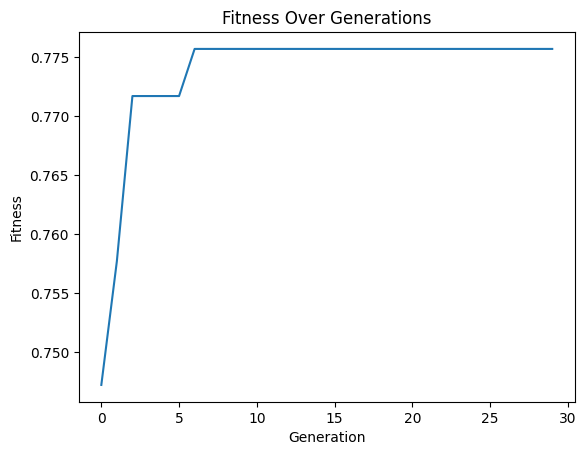

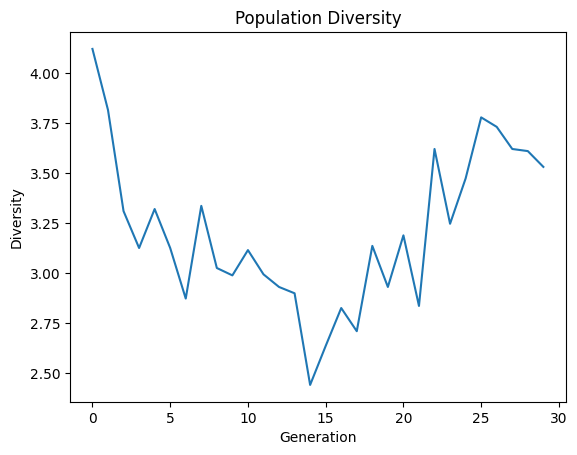

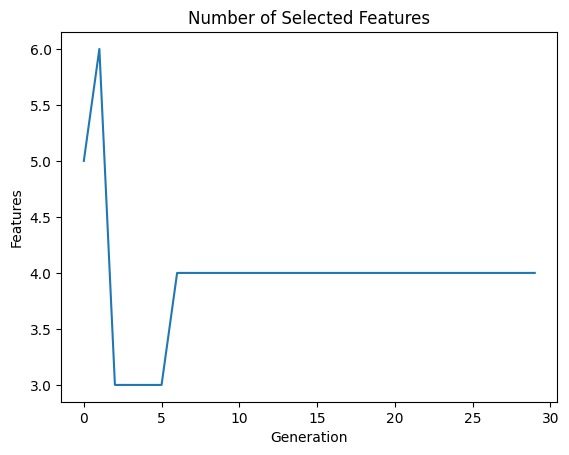

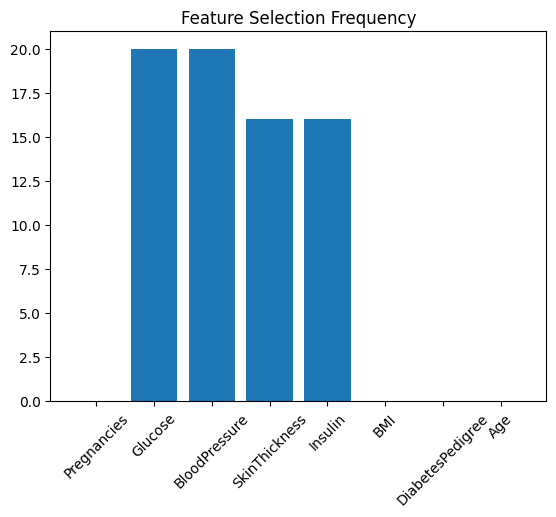

In [9]:
######   SVM   #######

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , roc_auc_score
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# ===============================
# Genetic Algorithm Class
# ===============================
class GeneticAlgorithmFeatureSelection:

    def __init__(self, X, y, pop_size=30, generations=50,
                 mutation_rate=0.05, crossover_rate=0.8,
                 selection_method="tournament",
                 crossover_method="single",
                 mutation_method="bitflip",
                 random_state=42):

        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.selection_method = selection_method
        self.crossover_method = crossover_method
        self.mutation_method = mutation_method

        self.n_features = X.shape[1]
        self.random_state = random_state

        # Memoization cache
        self.fitness_cache = {}

        # Train / Validation / Test split (60 / 20 / 20)
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=0.20, random_state=self.random_state)
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=self.random_state) # 0.25 * 0.8 = 0.2

        # Scaling
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_val = scaler.transform(self.X_val)
        self.X_test = scaler.transform(self.X_test)

    # ===============================
    # Chromosome
    # ===============================
    def create_chromosome(self):
        chromosome = np.random.randint(0, 2, self.n_features)
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1
        return chromosome

    # ===============================
    # Fitness Function
    # ===============================
    def fitness_svm(self, chromosome):

        chrom_tuple = tuple(chromosome)
        if chrom_tuple in self.fitness_cache:
            return self.fitness_cache[chrom_tuple]

        features = np.where(chromosome == 1)[0]
        if len(features) == 0:
            return 0

        model = SVC(kernel='rbf')  # you can also try 'linear'

        model.fit(self.X_train[:, features], self.y_train)

        preds = model.predict(self.X_val[:, features])

        acc = accuracy_score(self.y_val, preds)

        penalty = 0.02 * (len(features) / self.n_features)

        score = acc - penalty

        # ✅ VERY IMPORTANT
        self.fitness_cache[chrom_tuple] = score
        return score

    # ===============================
    # Selection Methods
    # ===============================
    def selection(self, population, fitness_scores):

        if self.selection_method == "tournament":
            i, j = random.sample(range(len(population)), 2)
            return population[i] if fitness_scores[i] > fitness_scores[j] else population[j]

        elif self.selection_method == "roulette":
            fitness_array = np.array(fitness_scores)
            total = fitness_array.sum()
            if total == 0:
                return population[np.random.randint(len(population))]
            probs = fitness_array / total
            idx = np.random.choice(len(population), p=probs)
            return population[idx]

        elif self.selection_method == "random":
            return population[np.random.randint(len(population))]

        elif self.selection_method == "rank":
            ranked = np.argsort(fitness_scores)
            probs = np.linspace(1, 2, len(population))
            probs = probs / probs.sum()
            idx = np.random.choice(ranked, p=probs)
            return population[idx]

    # ===============================
    # Crossover Methods
    # ===============================
    def crossover(self, p1, p2):

        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()

        if self.crossover_method == "single":
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])

        elif self.crossover_method == "two":
            pt1 = random.randint(1, self.n_features - 2)
            pt2 = random.randint(pt1, self.n_features - 1)
            c1 = p1.copy()
            c2 = p2.copy()
            c1[pt1:pt2] = p2[pt1:pt2]
            c2[pt1:pt2] = p1[pt1:pt2]

        elif self.crossover_method == "uniform":
            c1 = p1.copy()
            c2 = p2.copy()
            for i in range(self.n_features):
                if random.random() < 0.5:
                    c1[i] = p2[i]
                    c2[i] = p1[i]

        return c1, c2

    # ===============================
    # Mutation Methods
    # ===============================
    def mutation(self, chromosome):

        if self.mutation_method == "bitflip":
            for i in range(self.n_features):
                if random.random() < self.mutation_rate:
                    chromosome[i] = 1 - chromosome[i]

        elif self.mutation_method == "swap":
            i, j = np.random.randint(0, self.n_features, 2)
            chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

        elif self.mutation_method == "inversion":
            i, j = sorted(np.random.randint(0, self.n_features, 2))
            chromosome[i:j] = chromosome[i:j][::-1]

        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, self.n_features)] = 1

        return chromosome

    # ===============================
    # Run Genetic Algorithm
    # ===============================
    def run_5(self, verbose=True):

        population = [self.create_chromosome() for _ in range(self.pop_size)]

        best_chromosome = None
        best_fitness = -1

        fitness_history = []
        diversity_history = []
        feature_count_history = []

        for gen in range(self.generations):

            fitness_scores = [self.fitness_svm(c) for c in population]

            # Best individual
            idx = np.argmax(fitness_scores)
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_chromosome = population[idx].copy()

            fitness_history.append(best_fitness)
            feature_count_history.append(np.sum(best_chromosome))

            # Diversity (Vectorized Hamming Distance calculation)
            pop_array = np.array(population)
            # Efficiently compute average distance between all pairs
            # Matrix: (pop_size, pop_size)
            diff = (pop_array[:, None, :] != pop_array[None, :, :]).sum(axis=2)
            diversity = np.mean(diff[np.triu_indices(self.pop_size, k=1)])
            diversity_history.append(diversity)

            if verbose and (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}/{self.generations} | Best: {best_fitness:.4f} | Size: {np.sum(best_chromosome)}")

            # New population
            new_population = [best_chromosome]

            while len(new_population) < self.pop_size:
                p1 = self.selection(population, fitness_scores)
                p2 = self.selection(population, fitness_scores)

                c1, c2 = self.crossover(p1, p2)

                new_population.append(self.mutation(c1))
                if len(new_population) < self.pop_size:
                    new_population.append(self.mutation(c2))

            population = new_population

        return best_chromosome, best_fitness, fitness_history, diversity_history, feature_count_history


# ===============================
# Load Pima Dataset
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
    df = pd.read_csv(url, names=names)
    return df


# ===============================
# MAIN
# ===============================
def main():


    print("SELECTION METHODE : ROULETTE")
    print("CROSSOVER METHODE : UNIFORM")
    print("MUTATION METHODE : BITFLIP")

    df = load_data()
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    feature_names = X.columns

    # Baseline
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    baseline = accuracy_score(y_test, model.predict(X_test))
    print("Baseline Accuracy:", baseline)

    # Run GA
    ga = GeneticAlgorithmFeatureSelection(
        X.values, y.values,
        selection_method="roulette",
        crossover_method="single",
        mutation_method="bitflip",
        generations=30, # Reduced for faster demo
        pop_size=20
    )

    print("\nStarting Genetic Algorithm Evolution...")
    best_mask, best_fitness, fitness_hist, diversity_hist, feat_hist = ga.run_5()
    selected_features = [feature_names[i] for i in range(len(best_mask)) if best_mask[i]]

    # FINAL EVALUATION ON HELD-OUT TEST SET (Unseen by GA)
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(ga.X_train[:, best_mask == 1], ga.y_train)
    test_preds = final_model.predict(ga.X_test[:, best_mask == 1])
    final_test_acc = accuracy_score(ga.y_test, test_preds)

    print("\n" + "="*30)
    print("GA RESULTS")
    print("="*30)
    print(f"Best Validation Fitness: {best_fitness:.4f}")
    print(f"Final Test Accuracy:     {final_test_acc:.4f}")
    print(f"Selected Features ({len(selected_features)}): {selected_features}")
    print("="*30)

    # ===============================
    # Visualizations
    # ===============================
    plt.figure()
    plt.plot(fitness_hist)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.savefig("fitness.png")

    plt.figure()
    plt.plot(diversity_hist)
    plt.title("Population Diversity")
    plt.xlabel("Generation")
    plt.ylabel("Diversity")
    plt.savefig("diversity.png")

    plt.figure()
    plt.plot(feat_hist)
    plt.title("Number of Selected Features")
    plt.xlabel("Generation")
    plt.ylabel("Features")
    plt.savefig("features.png")

    # Feature frequency (Optimized with memoization)
    print("\nRunning Feature Frequency Analysis (20 runs)...")
    freq = np.zeros(len(feature_names))
    for i in range(20):
        # We reuse the same 'ga' object to benefit from the growing self.fitness_cache
        mask, _, _, _, _ = ga.run_5(verbose=False)
        freq += mask
        if (i+1) % 5 == 0:
            print(f"Completed {i+1}/20 runs...")

    plt.figure()
    plt.bar(feature_names, freq)
    plt.xticks(rotation=45)
    plt.title("Feature Selection Frequency")
    plt.savefig("feature_frequency.png")


if __name__ == "__main__":
    main()